In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# Load one batch of CelebA for visualization
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
dataset = datasets.CelebA(root="./data", split="train", download=False, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)
x, _ = next(iter(loader))
x = x.to(device)

Using: cpu


In [8]:
# ===== CONFIGURATION =====  [PLAY] change any value below and rerun
T = 1000  # [PLAY] try 500, 2000
beta_start = 1e-4  # [PLAY] try 1e-5, 1e-3
beta_end = 0.02  # [PLAY] try 0.01, 0.05
schedule_type = "cosine"  # [PLAY] try "cosine"

# ===== DEFINE SCHEDULE =====
if schedule_type == "linear":
    betas = torch.linspace(beta_start, beta_end, T, device=device)
elif schedule_type == "cosine":
    def cosine_betas(T, s=0.008):
        t = torch.arange(T + 1, device=device)
        f_t = torch.cos((t / T + s) / (1 + s) * torch.pi / 2) ** 2
        alphas_bar = f_t / f_t[0]
        betas = 1 - alphas_bar[1:] / alphas_bar[:-1]
        return torch.clip(betas, max=0.999)
    betas = cosine_betas(T)

# Precompute all alpha values
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)  # ᾱ_t
sqrt_alphas_bar = torch.sqrt(alphas_bar)
sqrt_one_minus_alphas_bar = torch.sqrt(1 - alphas_bar)

print(f"ᾱ_1 = {alphas_bar[0]:.6f}, ᾱ_{T} = {alphas_bar[-1]:.6f}")
print(f"beta_1 = {betas[0]:.6f}, beta_{T} = {betas[-1]:.6f}")

ᾱ_1 = 0.999959, ᾱ_1000 = 0.000000
beta_1 = 0.000041, beta_1000 = 0.999000


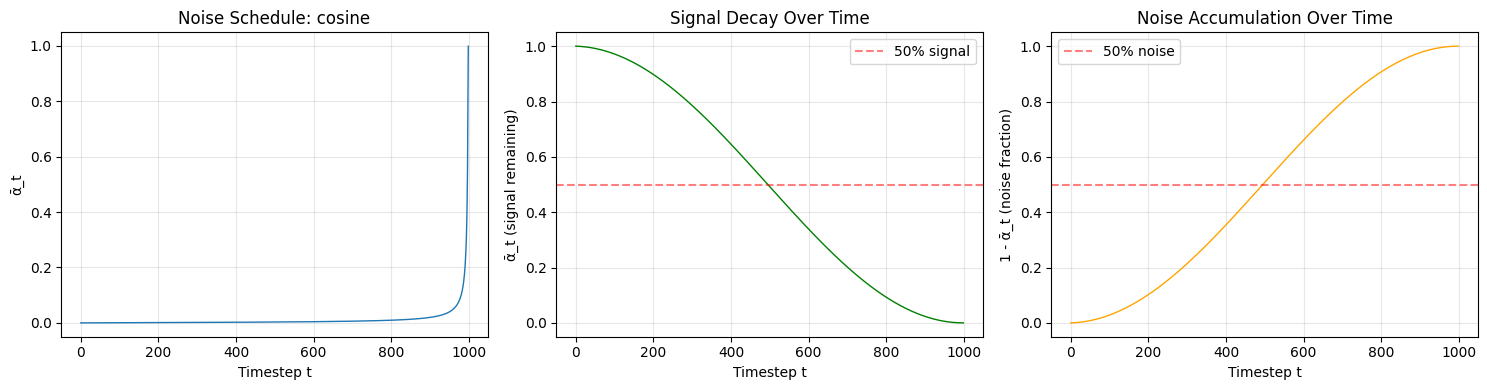

In [9]:
# Plot the schedule — [PLAY] try linear vs cosine
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Beta values across steps
axes[0].plot(betas.cpu(), linewidth=1)
axes[0].set_xlabel("Timestep t")
axes[0].set_ylabel("ᾱ_t")
axes[0].set_title(f"Noise Schedule: {schedule_type}")
axes[0].grid(alpha=0.3)

# Signal retention ᾱ_t
axes[1].plot(alphas_bar.cpu(), linewidth=1, color="green")
axes[1].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="50% signal")
axes[1].set_xlabel("Timestep t")
axes[1].set_ylabel("ᾱ_t (signal remaining)")
axes[1].set_title("Signal Decay Over Time")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Noise level 1-ᾱ_t
axes[2].plot((1 - alphas_bar).cpu(), linewidth=1, color="orange")
axes[2].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="50% noise")
axes[2].set_xlabel("Timestep t")
axes[2].set_ylabel("1 - ᾱ_t (noise fraction)")
axes[2].set_title("Noise Accumulation Over Time")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

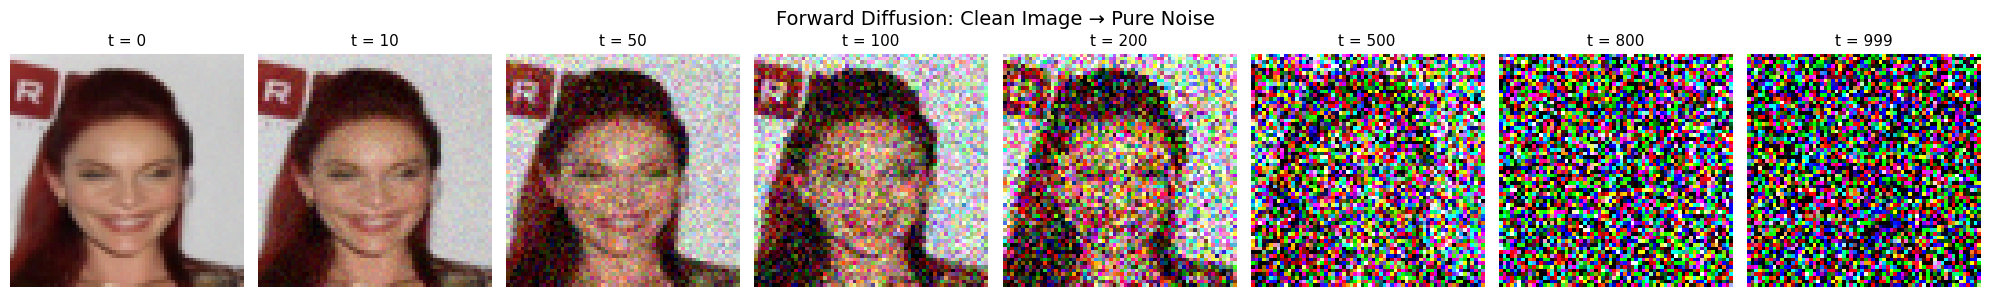

In [10]:
# ===== CLOSED-FORM FORWARD DIFFUSION =====
def forward_diffusion(x0, t, sqrt_alphas_bar, sqrt_one_minus_alphas_bar):
    """
    Jump directly from clean x0 to noisy xt in one step.
    
    Args:
        x0: clean image [B, C, H, W]
        t: timestep scalar or [B] tensor
    Returns:
        xt: noisy image at step t
        noise: the noise that was added
    """
    noise = torch.randn_like(x0)
    sqrt_alpha_t = sqrt_alphas_bar[t].view(-1, 1, 1, 1)
    sqrt_one_minus_t = sqrt_one_minus_alphas_bar[t].view(-1, 1, 1, 1)
    xt = sqrt_alpha_t * x0 + sqrt_one_minus_t * noise
    return xt, noise


# Sample steps to visualize
sample_steps = [0, 10, 50, 100, 200, 500, 800, 999]
img_idx = 0  # [PLAY] try different faces

x0 = x[img_idx:img_idx+1]  # keep batch dim

fig, axes = plt.subplots(1, len(sample_steps), figsize=(20, 3))
for i, t in enumerate(sample_steps):
    t_tensor = torch.tensor([t], device=device)
    xt, _ = forward_diffusion(x0, t_tensor, sqrt_alphas_bar, sqrt_one_minus_alphas_bar)
    axes[i].imshow(xt[0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f"t = {t}", fontsize=11)
    axes[i].axis("off")

plt.suptitle("Forward Diffusion: Clean Image → Pure Noise", fontsize=14)
plt.tight_layout()
plt.show()

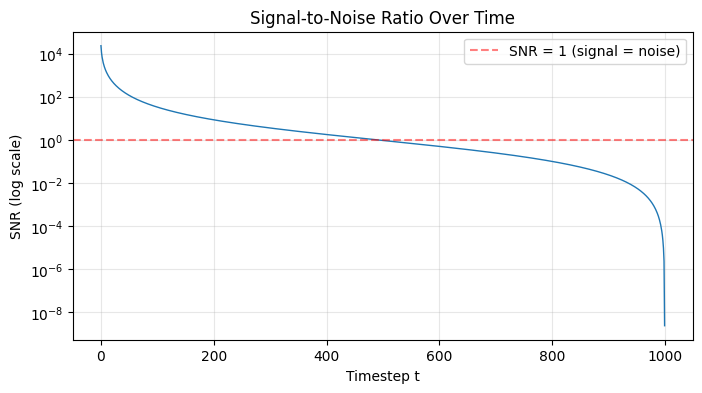

In [11]:
snr = alphas_bar / (1 - alphas_bar + 1e-8)

plt.figure(figsize=(8, 4))
plt.plot(snr.cpu(), linewidth=1)
plt.yscale("log")
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="SNR = 1 (signal = noise)")
plt.xlabel("Timestep t")
plt.ylabel("SNR (log scale)")
plt.title("Signal-to-Noise Ratio Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

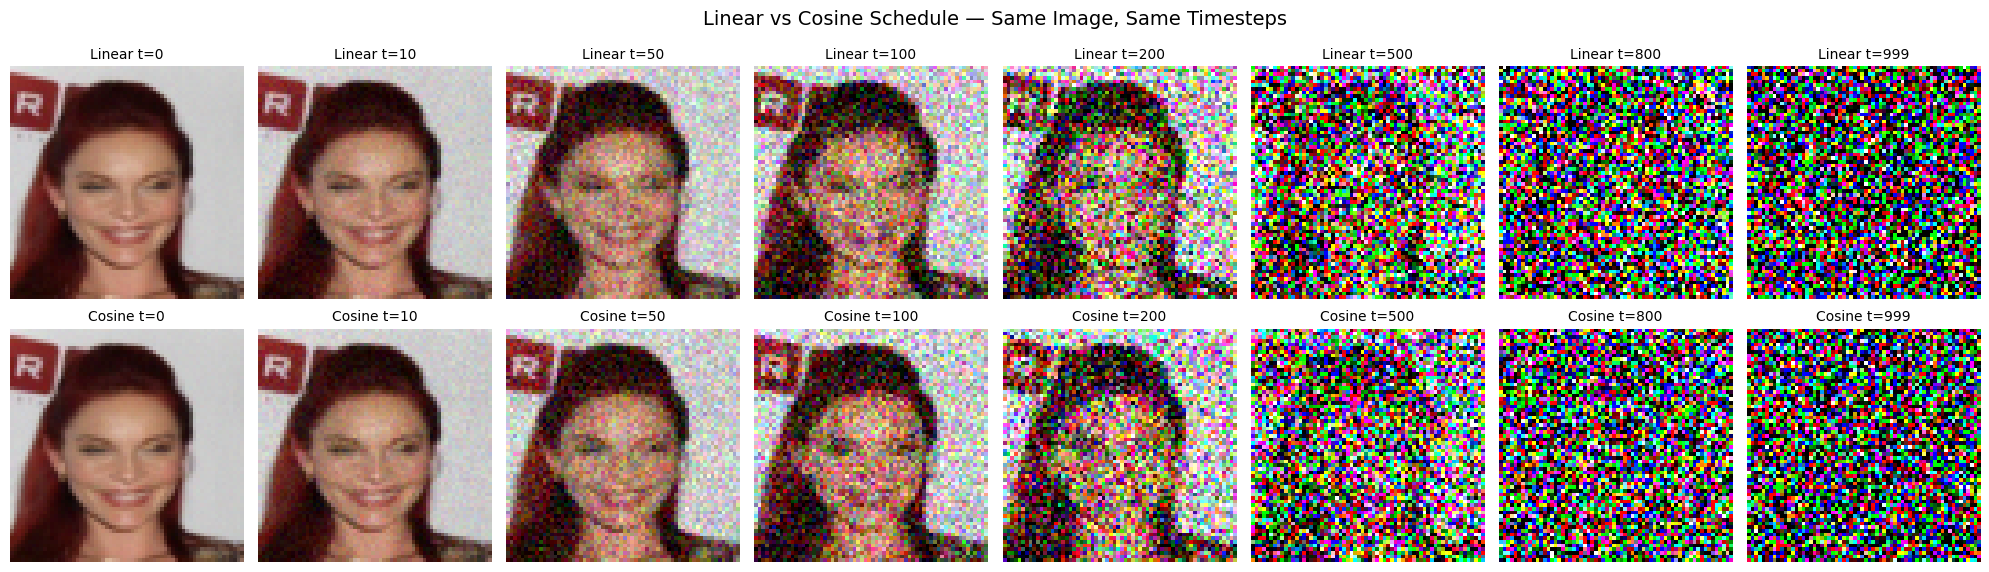

In [12]:
# [PLAY] compare linear vs cosine for the same image at the same steps
def prepare_schedule(betas_schedule, T, device):
    betas = betas_schedule.to(device)
    alphas = 1 - betas
    alphas_bar = torch.cumprod(alphas, dim=0)
    return torch.sqrt(alphas_bar), torch.sqrt(1 - alphas_bar)

# Cosine schedule
cosine_betas_tensor = cosine_betas(T)
sqrt_ab_cos, sqrt_1m_cos = prepare_schedule(cosine_betas_tensor, T, device)

# Linear schedule (already have sqrt_alphas_bar, sqrt_one_minus_alphas_bar)
sqrt_ab_lin = sqrt_alphas_bar
sqrt_1m_lin = sqrt_one_minus_alphas_bar

fig, axes = plt.subplots(2, len(sample_steps), figsize=(20, 6))

for i, t in enumerate(sample_steps):
    t_tensor = torch.tensor([t], device=device)
    
    # Linear
    xt_lin, _ = forward_diffusion(x0, t_tensor, sqrt_ab_lin, sqrt_1m_lin)
    axes[0, i].imshow(xt_lin[0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[0, i].set_title(f"Linear t={t}", fontsize=10)
    axes[0, i].axis("off")
    
    # Cosine
    xt_cos, _ = forward_diffusion(x0, t_tensor, sqrt_ab_cos, sqrt_1m_cos)
    axes[1, i].imshow(xt_cos[0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[1, i].set_title(f"Cosine t={t}", fontsize=10)
    axes[1, i].axis("off")

plt.suptitle("Linear vs Cosine Schedule — Same Image, Same Timesteps", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
def ddpm_loss(model, x0, t, sqrt_alphas_bar, sqrt_one_minus_alphas_bar):
    """
    Simplified ELBO loss: predict the noise.
    
    Args:
        model: noise predictor ε_θ(x_t, t)
        x0: clean image [B, C, H, W]
        t: random timesteps [B]
    """
    # Forward: add noise to x0
    noise = torch.randn_like(x0)
    xt = sqrt_alphas_bar[t].view(-1, 1, 1, 1) * x0 + \
         sqrt_one_minus_alphas_bar[t].view(-1, 1, 1, 1) * noise
    
    # Predict noise
    noise_pred = model(xt, t)
    
    # Simple MSE loss
    loss = torch.nn.functional.mse_loss(noise_pred, noise)
    return loss